In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\fraud-detection')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

cc = pd.read_csv('data/raw/creditcard.csv')
print(f"Shape: {cc.shape}")
print(f"\nColumns: {cc.columns.tolist()}")
print(f"\nData types:\n{cc.dtypes}")

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [2]:
print("=== Missing Values ===")
print(cc.isnull().sum().sum())

print("\n=== Duplicates ===")
print(f"Duplicate rows: {cc.duplicated().sum()}")

print("\n=== Class Distribution ===")
print(cc['Class'].value_counts())
print(f"Fraud rate: {cc['Class'].mean()*100:.4f}%")

print("\n=== Amount Stats ===")
print(cc['Amount'].describe().round(2))

=== Missing Values ===
0

=== Duplicates ===
Duplicate rows: 1081

=== Class Distribution ===
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%

=== Amount Stats ===
count    284807.00
mean         88.35
std         250.12
min           0.00
25%           5.60
50%          22.00
75%          77.16
max       25691.16
Name: Amount, dtype: float64


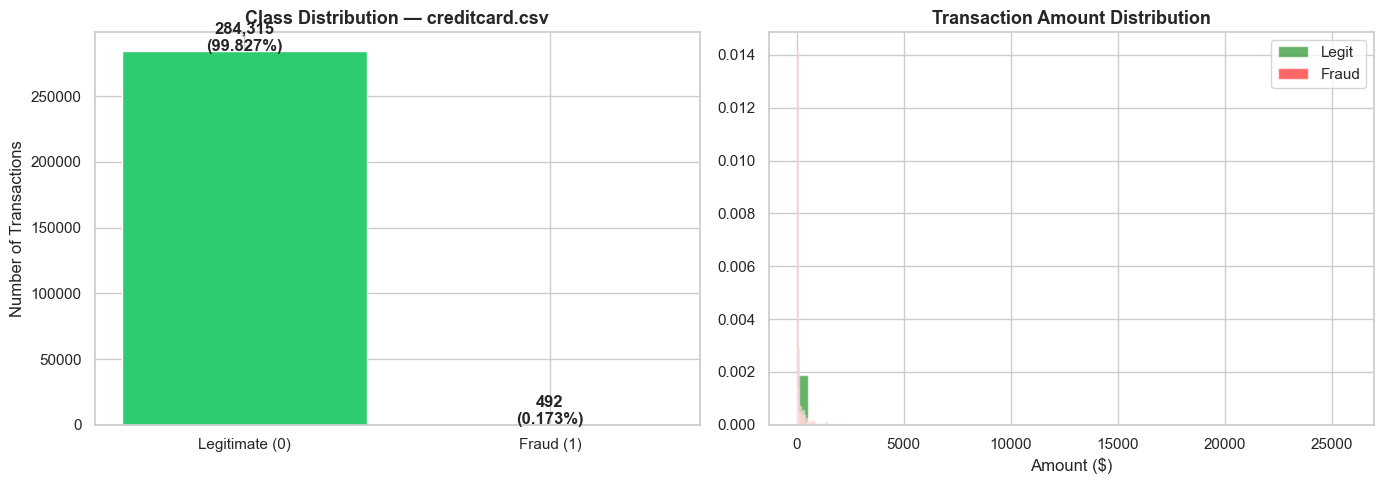

Plot 1 saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = cc['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Class Distribution — creditcard.csv', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+100, f'{v:,}\n({v/len(cc)*100:.3f}%)',
                 ha='center', fontweight='bold')

# Amount distribution fraud vs legit
axes[1].hist(cc[cc['Class']==0]['Amount'], bins=50, alpha=0.6,
             color='green', label='Legit', density=True)
axes[1].hist(cc[cc['Class']==1]['Amount'], bins=50, alpha=0.6,
             color='red', label='Fraud', density=True)
axes[1].set_title('Transaction Amount Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('notebooks/cc_plot1_class_imbalance.png', dpi=150)
plt.show()
print("Plot 1 saved!")

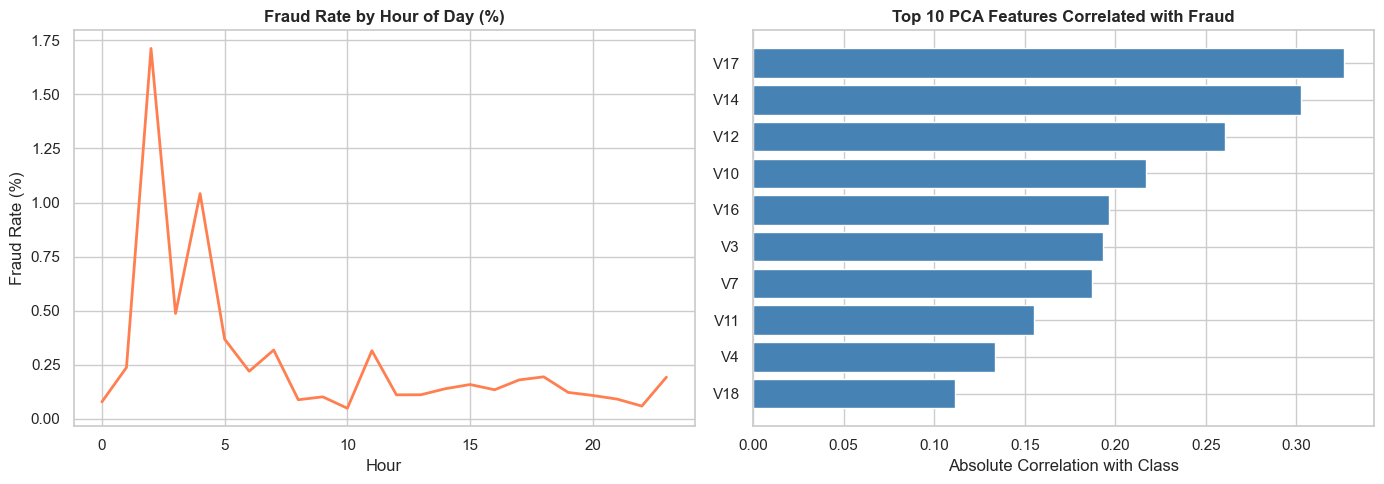

Plot 2 saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate over time
cc['time_hour'] = (cc['Time'] / 3600) % 24
time_bins = pd.cut(cc['time_hour'], bins=24)
fraud_by_time = cc.groupby(time_bins)['Class'].mean() * 100
axes[0].plot(range(len(fraud_by_time)), fraud_by_time.values, color='coral', linewidth=2)
axes[0].set_title('Fraud Rate by Hour of Day (%)', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate (%)')

# Top PCA features correlated with fraud
v_cols = [f'V{i}' for i in range(1, 29)]
correlations = cc[v_cols + ['Class']].corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top10 = correlations.head(10)
axes[1].barh(top10.index[::-1], top10.values[::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 PCA Features Correlated with Fraud', fontweight='bold')
axes[1].set_xlabel('Absolute Correlation with Class')

plt.tight_layout()
plt.savefig('notebooks/cc_plot2_features.png', dpi=150)
plt.show()
print("Plot 2 saved!")

In [5]:
# Drop raw Time, keep time_hour
cc_processed = cc.drop(columns=['Time']).copy()

os.makedirs('data/processed', exist_ok=True)
cc_processed.to_csv('data/processed/creditcard_features.csv', index=False)
print(f"Saved: {cc_processed.shape}")
print(f"Fraud rate: {cc_processed['Class'].mean()*100:.4f}%")
cc_processed.head()

Saved: (284807, 31)
Fraud rate: 0.1727%


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,time_hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.000278
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.000278
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.000556
